# DATA 30100  Fall 2025
# Homework 1: Data Collection and Missing Data (50 points)

Please complete this notebook by filling in the cells provided.

The solved homework should be uploaded to Canvas as an .ipynb file. DO NOT put your answers in more than one file or use a different file extension.

Make sure to RUN ALL CELLS IN YOUR NOTEBOOK before submitting.  All of your answers should be printed and easy for the instructor to find if you want full credit for your work.

You should work independently unless it is clearly allowed to collaborate.

Homework 1 is due on **Thursday, October 16, at 9:00am**. Late work will not be accepted.  

In [2]:
# Importing libraries
import numpy as np
import pandas as pd
import warnings
warnings.simplefilter('ignore', FutureWarning)

import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

## 1.  EM algorithm for bivariate normal data (20 points)

As in Lecture 3, we assume that we have data from the bivariate normal distribution:
$${\displaystyle {\begin{pmatrix}X\\Y\end{pmatrix}}\sim {\mathcal {N}}\left({\begin{pmatrix}\mu _{X}\\\mu _{Y}\end{pmatrix}},{\begin{pmatrix}\sigma _{X}^{2}&\rho \sigma _{X}\sigma _{Y}\\\rho \sigma _{X}\sigma _{Y}&\sigma _{Y}^{2}\end{pmatrix}}\right)}$$


Assume that we have $n$ pairs of observations from this distribution with some of them missing either $X$ or $Y$, completely at random. 


**Question 1.** Similar to the lectures, write a function that simulates $n$ samples from a bivariate normal with given mean and covariance, such that:

- each pair has a probability $f$ to have missing data ($0<f<1$);
- for each pair with missing data, you flip a fair coin to decide if $X$ is missing or if $Y$ is missing (only one is missing).

The function should return a data frame with 2 columns (named X amd Y) and $n$ rows.

In [2]:
# code here
def sim2norm(n,mean,cov,f):
    data = np.random.multivariate_normal(mean, cov, n)
    df = pd.DataFrame(data, columns=['X', 'Y'])

    for i in range(n):
        if np.random.rand() < f:
            if np.random.rand() < 0.5:
                df.loc[i, 'X'] = np.nan
            else:
                df.loc[i, 'Y'] = np.nan
    return df

In [3]:
# test your function here
mean = [2, 4]
cov = [[9, 1.5], [1.5, 1]] 
sim2norm(10,mean,cov,0.441)

,X,Y
0,-1.667119,5.123362
1,3.105168,NaN
2,0.710730,4.490151
3,2.528416,NaN
4,0.064480,4.290027
5,-2.119322,4.483168
6,0.757781,NaN
7,1.621243,NaN
8,2.751440,4.860091
9,3.834842,NaN


**Question 2.** Write a function that take as argument a dataframe with 2 columns and returns 3 estimates of the correlation between the two variables :
1. First estimate is obtained by deleting the rows with missing data and calculating the sample correlation of the remaining data;

2. Second estimate uses mean imputation for each variable (and then the correlation is calculated);

3. Third estimate of correlation is obtained using the EM algorithm.

**Note:** The EM algorithm is described in the notebook for Lecture 3. Implementing it requires the joint density of the bivariate normal, as well as the formula for the conditional distribution (distributions of $Y|X=x$ and $X|Y=y$). 

In [ ]:
# code here
def cor3est(df):
    # Method 1: Dropping missing values
    df1 = df.dropna()
    cor1 = df1['X'].corr(df1['Y'])

    # Method 2: Mean imputation
    df2 = df.copy()
    df2['X'].fillna(df2['X'].mean(), inplace=True)
    df2['Y'].fillna(df2['Y'].mean(), inplace=True)
    cor2 = df2['X'].corr(df2['Y'])

    # Method 3: EM algorithm
    df3 = df.copy()
    miss_x = df3.index[df3['X'].isnull()]
    miss_y = df3.index[df3['Y'].isnull()]


    mx = df3['X'].mean()
    my = df3['Y'].mean()
    sx = df3['X'].std()
    sy = df3['Y'].std()
    r = df3['X'].corr(df1['Y'])
    if pd.isna(r):
        r = 0
    
    num_iter = 100
    for num in range(num_iter):
        for i in miss_x:
            y_val = df3.loc[i, 'Y']
            df3.loc[i, 'X'] = mx + r * (sx / sy) * (y_val - my)

        for i in miss_y:
            x_val = df3.loc[i, 'X']
            df3.loc[i, 'Y'] = my + r * (sy / sx) * (x_val - mx)

        mx = df3['X'].mean()
        my = df3['Y'].mean()
        sx = df3['X'].std()
        sy = df3['Y'].std()
        r = df3['X'].corr(df3['Y'])

    cor3 = r
    return cor1, cor2, cor3

In [5]:
# test your function here
mean = [2, 4]
cov = [[9, 1.5], [1.5, 1]] 
cor3est(sim2norm(100,mean,cov,0.511))

(np.float64(0.5626911972613664),
 np.float64(0.3246109126616571),
 np.float64(0.7841827267611255))

**Question 3.** Here, we would like to understand the performance of each of the three estimators. For the specified simulation scenario in the cell code below (that shows values for $n$, mean, cov, $f$) perform 1000 simulations to evaluate the bias $(\hat\rho-\rho)$ and mean absolute error $|\hat\rho-\rho|$. Comment on your findings.

In [ ]:
n = 100
mean = [2, 4]
cov = [[9, 1.5], [1.5, 1]] 
f = 0.3
num_sim = 1000
rho = cov[0][1] / (np.sqrt(cov[0][0]) * np.sqrt(cov[1][1]))

result_del = []
result_mean = []
result_em = []

for num in range(num_sim):
    df = sim2norm(n, mean, cov, f)
    cor1, cor2, cor3 = cor3est(df)

    result_del.append(cor1)
    result_mean.append(cor2)
    result_em.append(cor3)

# Calculate biases
Bias_del = np.mean(result_del) - rho
Bias_mean = np.mean(result_mean) - rho
Bias_em = np.mean(result_em) - rho

# Calculate Mean Absolute Errors (MAE)
MAE_del = np.mean(np.abs(np.array(result_del) - rho))
MAE_mean = np.mean(np.abs(np.array(result_mean) - rho))
MAE_em = np.mean(np.abs(np.array(result_em) - rho))

# Print results
print(f"For Delete Method: Bias = {Bias_del}, MAE = {MAE_del}")
print(f"For Mean Method: Bias = {Bias_mean}, MAE = {MAE_mean}")
print(f"For EM Method: Bias = {Bias_em}, MAE = {MAE_em}")

For Delete Method: Bias = -0.0022320697467825834, MAE = 0.06982563676334184
For Mean Method: Bias = -0.09020615599548559, MAE = 0.10040697887321462
For EM Method: Bias = 0.07939514681496829, MAE = 0.10061899388366616


### **Findings**
#### For the Delete Method
It has the lowest bias and MAE, indicates that it is the best method for this dataset.

#### For the Mean Imputation method
It has the largest bias and the largest MAE, indicates that it is the worst method for this dataset.

#### For the EM Algorithm method
It has the second largest bias and the MAE, also indicates that it is not the best method for this dataset. This is actually not my expected: I assume that it is the best method, and probabaly is because the size of the dataset is small. Also, one thing interesting is that it's bias is the only positive value.

**Question 4.** Here we explore the impact of the correlation $\rho$; repeat your simulation for several different values of $\rho$ and report on your findings.

In [7]:
n = 100
mean = [2, 4]
f = 0.3
num_sim = 1000
rho_list = [0.1, 0.3, 0.5, 0.7, 0.9]

bias = {'Delete': [], 'Mean': [], 'EM': []}
mae = {'Delete': [], 'Mean': [], 'EM': []}

for rho in rho_list:
    cov = [[1, rho], [rho, 1]]

    result_del = []
    result_mean = []
    result_em = []
    
    for _ in range(num_sim):
        df = sim2norm(n, mean, cov, f)
        cor1, cor2, cor3 = cor3est(df)

        result_del.append(cor1)
        result_mean.append(cor2)
        result_em.append(cor3)

    # Calculate biases
    Bias_del = np.mean(result_del) - rho
    Bias_mean = np.mean(result_mean) - rho
    Bias_em = np.mean(result_em) - rho

    # Calculate Mean Absolute Errors (MAE)
    MAE_del = np.mean(np.abs(np.array(result_del) - rho))
    MAE_mean = np.mean(np.abs(np.array(result_mean) - rho))
    MAE_em = np.mean(np.abs(np.array(result_em) - rho))

    bias['Delete'].append(Bias_del)
    bias['Mean'].append(Bias_mean)
    bias['EM'].append(Bias_em)

    mae['Delete'].append(MAE_del)
    mae['Mean'].append(MAE_mean)
    mae['EM'].append(MAE_em)

final_results = pd.DataFrame({
    'Rho': rho_list,
    'Bias_Delete': bias['Delete'],
    'Bias_Mean': bias['Mean'],
    'Bias_EM': bias['EM'],
    'MAE_Delete': mae['Delete'],
    'MAE_Mean': mae['Mean'],
    'MAE_EM': mae['EM'],
})
print(final_results)

   Rho  Bias_Delete  Bias_Mean   Bias_EM  MAE_Delete  MAE_Mean    MAE_EM
0  0.1    -0.005181  -0.021995  0.018920    0.098774  0.083364  0.126173
1  0.3    -0.002815  -0.055515  0.064226    0.087181  0.086398  0.115034
2  0.5     0.000497  -0.088747  0.082558    0.071464  0.098742  0.104892
3  0.7    -0.001568  -0.126957  0.067562    0.049919  0.127696  0.074944
4  0.9    -0.001589  -0.162183  0.027237    0.018954  0.162183  0.028865


### **Findings**
#### For the Delete Method
The bias performs no correlation with $\rho$ value but the MAE falls as it rises. This shows that with higher $\rho$, the method is more accurate.

#### For the Mean Imputation method
The bias and the MAE become larger as $\rho$ value rises (the bias is larger meaning that it is more diverge than 0, but not the numerical meaning since the bias value is negative). This shows that with higher $\rho$, the method is less accurate.

#### For the EM Algorithm method
Same as the delete method, the bias performs no correlation with $\rho$ value but the MAE falls as it rises. This also shows that with higher $\rho$, the method is more accurate.

**Question 5.** Here we explore the impact of the fraction of missing data $f$; repeat your simulation for several different values of $f$ and report on your findings.

In [8]:
n = 100
mean = [2, 4]
cov = [[9, 1.5], [1.5, 1]] 
f_list = [0.1, 0.3, 0.5, 0.7]
num_sim = 1000
rho = cov[0][1] / (np.sqrt(cov[0][0]) * np.sqrt(cov[1][1]))

bias = {'Delete': [], 'Mean': [], 'EM': []}
mae = {'Delete': [], 'Mean': [], 'EM': []}

for f in f_list:

    result_del = []
    result_mean = []
    result_em = []
    
    for _ in range(num_sim):
        df = sim2norm(n, mean, cov, f)
        cor1, cor2, cor3 = cor3est(df)

        result_del.append(cor1)
        result_mean.append(cor2)
        result_em.append(cor3)

    # Calculate biases
    Bias_del = np.mean(result_del) - rho
    Bias_mean = np.mean(result_mean) - rho
    Bias_em = np.mean(result_em) - rho

    # Calculate Mean Absolute Errors (MAE)
    MAE_del = np.mean(np.abs(np.array(result_del) - rho))
    MAE_mean = np.mean(np.abs(np.array(result_mean) - rho))
    MAE_em = np.mean(np.abs(np.array(result_em) - rho))

    bias['Delete'].append(Bias_del)
    bias['Mean'].append(Bias_mean)
    bias['EM'].append(Bias_em)

    mae['Delete'].append(MAE_del)
    mae['Mean'].append(MAE_mean)
    mae['EM'].append(MAE_em)

final_results = pd.DataFrame({
    'F': f_list,
    'Bias_Delete': bias['Delete'],
    'Bias_Mean': bias['Mean'],
    'Bias_EM': bias['EM'],
    'MAE_Delete': mae['Delete'],
    'MAE_Mean': mae['Mean'],
    'MAE_EM': mae['EM'],
})
print(final_results)

     F  Bias_Delete  Bias_Mean   Bias_EM  MAE_Delete  MAE_Mean    MAE_EM
0  0.1    -0.001401  -0.028172  0.019955    0.063878  0.065545  0.066898
1  0.3    -0.001959  -0.090838  0.081078    0.071660  0.101015  0.102209
2  0.5    -0.008281  -0.173291  0.174284    0.086980  0.174251  0.182371
3  0.7    -0.007781  -0.272360  0.312857    0.110840  0.272360  0.318751


### **Findings**
#### For the Delete Method
The bias shows no correlation with F value and is always close to 0. However, the MAE rises at the slowest rate as F rises. This shows that it is the best method for the dataset no matter what the F value is.

#### For the Mean Imputation method
Both the bias and MAE rises as F rises.

#### For the EM Algorithm method
Same as the Mean Imputation method, both the bias and MAE rises as F rises.

## 2.  Response bias and randomized responses (15 points)

We talked in class about response bias and the the following scheme that gives subjects **plausabile deniability.**

<div>
<img src="notebook): randomized_response.png" width="600"/>
</div>

Assume we perform a study with a sample size of $n$ that attempts to estimate the proportion $s$ in the population of people who use chatGPT for writing their emails.

**Question 1**. Write a function named `response_bias`that
- repeats the following `nsim` times:
- simulates $n$ subjects from a population where $s$ is the true value
- estimates $s$ as the sample proportion (using all n subjects)
- performs the randomized procedure in the scheme above with the specified values for $p$ and $q$
- estimates $s$ as discussed in class from the randomized data
- the function returns the estimated mean squared errors for the two estimators (using all subjects, and using the randomized data)

In [9]:
# code here
def response_bias(n,s,p,q,nsim):
    direct = []
    random = []
    for _ in range(nsim):

        # Direct response
        true_response = np.random.binomial(1, s, size=n)
        s_hat_d = np.mean(true_response)
        direct.append(s_hat_d)

        # Randomized response
        truth = np.random.rand(n) < p
        Not_truth = np.random.binomial(1, 1-q, size=n)
        random_response = np.where(truth, true_response, Not_truth)
        mean_random = np.mean(random_response)
        if p > 0:
            s_hat_r = (mean_random - (1-p)*(1-q)) / p
            random.append(s_hat_r)
        else:
            random.append(np.nan)
        
        # Calculate MSE
    mse_d = np.mean((np.array(direct) - s) ** 2)
    mse_r = np.mean((np.array(random) - s) ** 2)

    return mse_d, mse_r

**Question 2**. Use the function you wrote to understand the impact of the choice of $p$ on mean squared error when $n=100$ and $q=1/2$. This is intentionally vague, as we want you to decide what numerical and/or graphical summaries are useful.

     p  MSE_Direct  MSE_Randomized
0  0.1    0.002096        0.261435
1  0.2    0.002242        0.060850
2  0.3    0.002003        0.026587
3  0.4    0.002088        0.014808
4  0.5    0.002119        0.009172
5  0.6    0.002035        0.006378
6  0.7    0.002101        0.004830
7  0.8    0.002181        0.003574
8  0.9    0.002012        0.002478


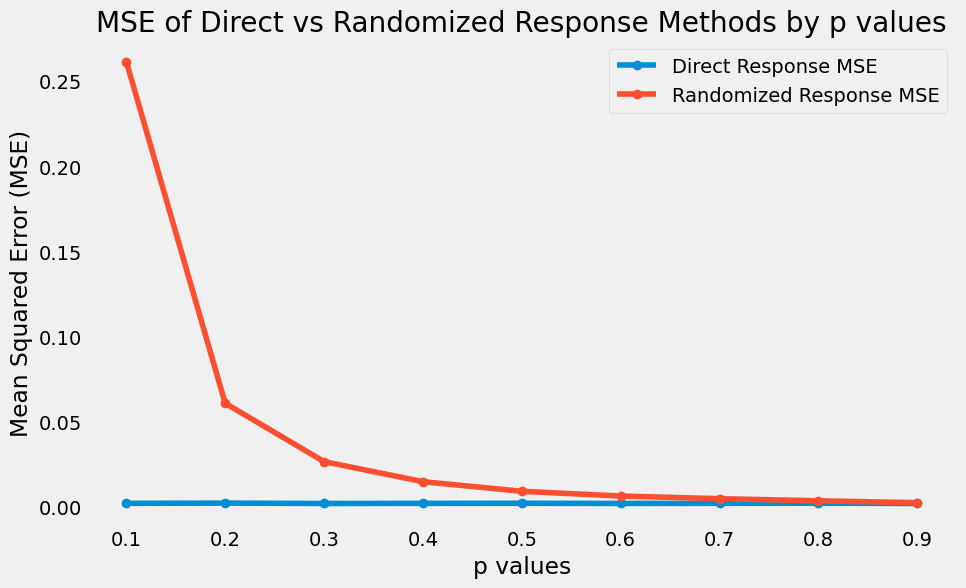

In [10]:
n = 100
q = 1/2
s = 0.3
nsim = 2000
p_values = np.linspace(0.1, 0.9, 9)

mse_d_result = []
mse_r_result = []

for p in p_values:
    mse_d, mse_r = response_bias(n, s, p, q, nsim)
    mse_d_result.append(mse_d)
    mse_r_result.append(mse_r)

# Numerical results
result_numeric = pd.DataFrame({
    'p': p_values,
    'MSE_Direct': mse_d_result,
    'MSE_Randomized': mse_r_result
})
print(result_numeric)

# Graphical results
plt.figure(figsize=(10, 6))
plt.plot(p_values, mse_d_result, marker='o', label='Direct Response MSE')
plt.plot(p_values, mse_r_result, marker='o', label='Randomized Response MSE')
plt.xlabel('p values')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('MSE of Direct vs Randomized Response Methods by p values')
plt.legend()
plt.grid()
plt.show()

### **Findings**
- As p-Value goes up, the randomized response MSE goes down and closer to the direct response MSE. This is because that the situation of direct response is the randomized response when p values equals to one. 

- The randomized response MSE drops dramatically at the first because the ratio of true answers increases a lot, which reduce the random noise sharply.

- With the increase of the p-value, the marginal improvement decrease, so the curve becomes flatten.

- Besides, the direct response MSE is always close to zero (or we can treat it as always to be zero) no matter what the p-value is.

**Question 3**. Use the function you wrote to understand the impact of $q$ on mean squared error when $n=100$ and $p=1/2$.

     q  MSE_Direct  MSE_Randomized
0  0.1    0.002216        0.009877
1  0.2    0.002158        0.010162
2  0.3    0.002107        0.010182
3  0.4    0.002135        0.010221
4  0.5    0.002118        0.009439
5  0.6    0.002104        0.009154
6  0.7    0.002156        0.008463
7  0.8    0.002015        0.007153
8  0.9    0.002186        0.006724


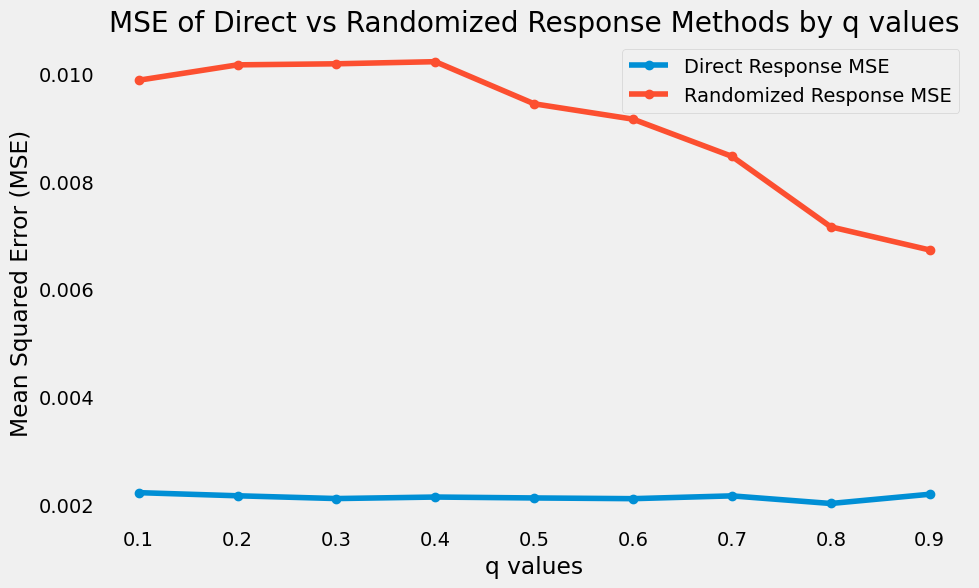

In [11]:
n = 100
p = 1/2
s = 0.3
nsim = 2000
q_values = np.linspace(0.1, 0.9, 9)

mse_d_result = []
mse_r_result = []

for q in q_values:
    mse_d, mse_r = response_bias(n, s, p, q, nsim)
    mse_d_result.append(mse_d)
    mse_r_result.append(mse_r)

# Numerical results
result_numeric = pd.DataFrame({
    'q': q_values,
    'MSE_Direct': mse_d_result,
    'MSE_Randomized': mse_r_result
})
print(result_numeric)

# Graphical results
plt.figure(figsize=(10, 6))
plt.plot(q_values, mse_d_result, marker='o', label='Direct Response MSE')
plt.plot(q_values, mse_r_result, marker='o', label='Randomized Response MSE')
plt.xlabel('q values')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('MSE of Direct vs Randomized Response Methods by q values')
plt.legend()
plt.grid()
plt.show()

### **Findings**
- As q-value goes up, the randomized response MSE goes up at first and decreases at about q=0.4. This is because that when q is around the middle range, the randomness is the most unpredictable, which create the largest noise.

- After q=0.4, the randomized response MSE drops, which is due to higher predictability.

- Even when randomized response MSE drops gradually, there is still a big difference from the dirct response MSE.

- Besides, the direct response MSE is always close to zero (or we can treat it as always to be zero) no matter what the q value is.

## 3.  Data collection and exploring Nobel prize data (15 points)

This question asks you to do a bit of exploratory data analysis on Nobel prize winners. There are many datasets available; one dataset that is easily accesible is on Kaggle: https://www.kaggle.com/datasets/nobelfoundation/nobel-laureates

This Kaggle dataset is incomplete because it only contains the prizes before 2016. 

**Question 1 (For this question you are allowed to collaborate with other students in the course).** Construct a complete dataset (up to 2025 - some have been awarded this week!) that has the same variables as the one in Kaggle; it should be saved in a CSV file named `nobel30100.csv` . The data are avalaible here: https://www.nobelprize.org/prizes/lists/all-nobel-prizes/

You can use a web scraper package (like `beautifulsoup`) or the Nobel Foundation API: https://www.nobelprize.org/organization/developer-zone-2/


In [4]:
import requests

old_file = pd.read_csv('Nobel_archive.csv')
new_list = []

for year in range(2017, 2026):
    url = requests.get(f"https://api.nobelprize.org/2.1/nobelPrizes?nobelPrizeYear={year}")    
    prizes = url.json()

    for prize in prizes.get('nobelPrizes', []):

        for winner_profile in prize.get('laureates', []):
            laureate_id = winner_profile.get('id')
                
            if laureate_id:
                url_laureate = f"https://api.nobelprize.org/2.1/laureate/{laureate_id}" 
                winner_detail = requests.get(url_laureate)

                if winner_detail.status_code != 200 or not winner_detail.text:
                    continue
                winner = winner_detail.json()[0]

                affiliations = [i
                                 for a in winner.get("nobelPrizes", [])
                                 for i in a.get("affiliations", [])]

                full_name = winner.get('knownName', {}).get('en') or winner.get('orgName', {}).get('en')
                birth_info = winner.get('birth', {})
                death_info = winner.get('death', {})
                
                if not affiliations:
                    winner_dict = {
                        'Year': year,
                        'Category': prize.get('category', {}).get('en'),
                        'Prize': f"The Nobel Prize in {prize.get('category', {}).get('en')}",
                        'Motivation': winner_profile.get('motivation', {}).get('en'),
                        'Prize Share': winner_profile.get('portion'),
                        'Laureate ID': laureate_id,
                        'Laureate Type': 'Organization' if 'orgName' in winner else 'Individual',
                        'Full Name': full_name,
                        'Birth Date': birth_info.get('date'),
                        'Birth City': birth_info.get('place', {}).get('city', {}).get('en'),
                        'Birth Country': birth_info.get('place', {}).get('country', {}).get('en'),
                        'Sex': winner.get('gender'),
                        'Organization Name': None,
                        'Organization City': None,
                        'Organization Country': None,
                        'Death Date': death_info.get('date'),
                        'Death City': death_info.get('place', {}).get('city', {}).get('en'),
                        'Death Country': death_info.get('place', {}).get('country', {}).get('en')
                    }
                    new_list.append(winner_dict)
                else:
                    for i in affiliations:
                        winner_dict = {
                            'Year': year,
                            'Category': prize.get('category', {}).get('en'),
                            'Prize': f"The Nobel Prize in {prize.get('category', {}).get('en')}",
                            'Motivation': winner_profile.get('motivation', {}).get('en'),
                            'Prize Share': winner_profile.get('portion'),
                            'Laureate ID': laureate_id,
                            'Laureate Type': 'Organization' if 'orgName' in winner else 'Individual',
                            'Full Name': full_name,
                            'Birth Date': birth_info.get('date'),
                            'Birth City': birth_info.get('place', {}).get('city', {}).get('en'),
                            'Birth Country': birth_info.get('place', {}).get('country', {}).get('en'),
                            'Sex': winner.get('gender'),
                            'Organization Name': i.get('name', {}).get('en'),
                            'Organization City': i.get('city', {}).get('en'),
                            'Organization Country': i.get('country', {}).get('en'),
                            'Death Date': death_info.get('date'),
                            'Death City': death_info.get('place', {}).get('city', {}).get('en'),
                            'Death Country': death_info.get('place', {}).get('country', {}).get('en')
                            }
                        new_list.append(winner_dict)

new_df = pd.DataFrame(new_list)
final_df = pd.concat([old_file, new_df], ignore_index=True)
final_df.sort_values(by='Year', inplace=True)
replace_map1 = {'male':'Male', 'female':'Female'}
replace_map2 = {'Economic Sciences':'Economics', 'Physiology or Medicine':'Medicine'}
final_df.replace({'Sex': replace_map1}, inplace=True)
final_df.replace({'Category': replace_map2}, inplace=True)
final_df.to_csv('nobel30100.csv', index=False)


In [5]:
# specify the correct path to where the file is
# and run this so we see the size of the file you constructed
nobel_df = pd.read_csv("nobel30100.csv")
print(nobel_df.shape)
nobel_df.head(5)

(1112, 18)


,Year,Category,Prize,Motivation,Prize Share,Laureate ID,Laureate Type,Full Name,Birth Date,Birth City,Birth Country,Sex,Organization Name,Organization City,Organization Country,Death Date,Death City,Death Country
0,1901,Chemistry,The Nobel Prize in Chemistry 1901,"""in recognition of the extraordinary services ...",1/1,160,Individual,Jacobus Henricus van 't Hoff,1852-08-30,Rotterdam,Netherlands,Male,Berlin University,Berlin,Germany,1911-03-01,Berlin,Germany
1,1901,Literature,The Nobel Prize in Literature 1901,"""in special recognition of his poetic composit...",1/1,569,Individual,Sully Prudhomme,1839-03-16,Paris,France,Male,NaN,NaN,NaN,1907-09-07,Châtenay,France
2,1901,Medicine,The Nobel Prize in Physiology or Medicine 1901,"""for his work on serum therapy, especially its...",1/1,293,Individual,Emil Adolf von Behring,1854-03-15,Hansdorf (Lawice),Prussia (Poland),Male,Marburg University,Marburg,Germany,1917-03-31,Marburg,Germany
3,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,462,Individual,Jean Henry Dunant,1828-05-08,Geneva,Switzerland,Male,NaN,NaN,NaN,1910-10-30,Heiden,Switzerland
4,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,463,Individual,Frédéric Passy,1822-05-20,Paris,France,Male,NaN,NaN,NaN,1912-06-12,Paris,France


**Question 2 (For this question you should work independently).**  Perform some exploratory data analysis (numerical and graphical summaries of data). Identify something interesting that you want to highlight, and comment on it. Please only show what is interesting (and not your full exploration of the data).

Note that the Kaggle page in their **Inspiration** section asks some questions you can consider: *Which country has won the most prizes in each category? What words are most frequently written in the prize motivation?*

Sex         Female  Male  Total  Female Proportion (%)
Category                                              
Chemistry        7   191    198                   3.54
Economics        3    96     99                   3.03
Literature      18   104    122                  14.75
Medicine        14   218    232                   6.03
Peace           20    91    111                  18.02
Physics          5   223    228                   2.19


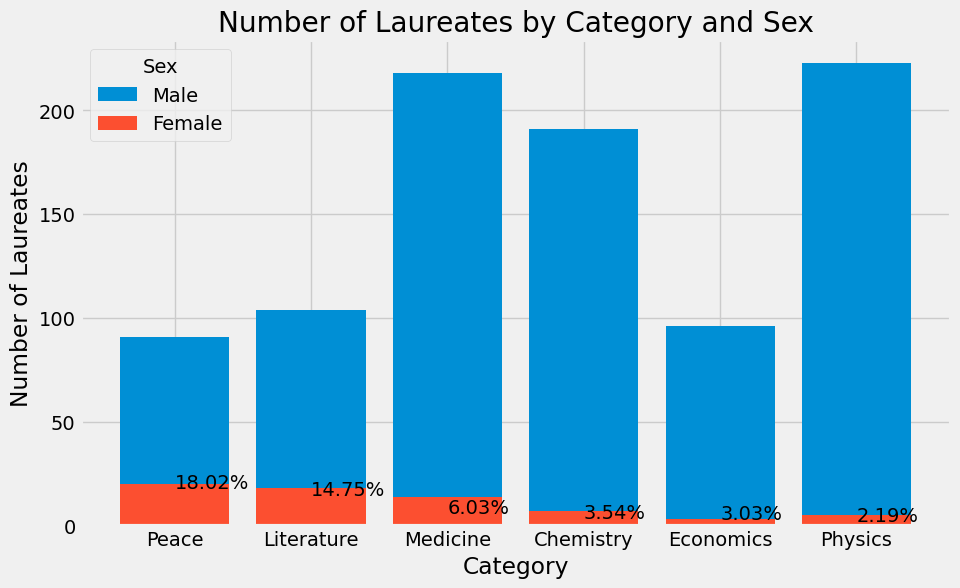

In [13]:
# Number of Laureates by Category and Sex Ratio

df = final_df.copy()
df = df.drop_duplicates(subset=['Laureate ID'])
df = df.dropna(subset=['Sex'])
counts = df.groupby(['Category', 'Sex']).size().unstack()
counts['Total'] = counts.Male + counts.Female
counts['Female Proportion (%)'] = (counts.Female / counts['Total'] * 100).round(2)
print(counts)

sorted_counts = counts.sort_values(by='Female Proportion (%)', ascending=False)
plt.figure(figsize=(10, 6))
plt.bar(sorted_counts.index, sorted_counts['Male'], label='Male')
plt.bar(sorted_counts.index, sorted_counts['Female'], label='Female')
plt.title('Number of Laureates by Category and Sex')
plt.xlabel('Category')
plt.ylabel('Number of Laureates')
for i, proportion in enumerate(sorted_counts['Female Proportion (%)']):
    plt.text(i, proportion, f'{proportion}%')
plt.legend(title='Sex')
plt.show()

### **Findings**
It is not surprising that the female ratio of winning the nobel prize to be much lower than mens. So I want to look at in what area does the female have higher chances to win the prize. It is interesting that in humanities' subjects (peace and literature), female has a significant higher ratio than science subjects (Chemistry, Economics, and Physics). Medicine is the subject in the middle.

Sex        Female  Male  Total  Female Ratio (%)
Period                                          
1901-1945       9   209    218              4.13
1946-1999      20   445    465              4.30
2000-2025      38   269    307             12.38


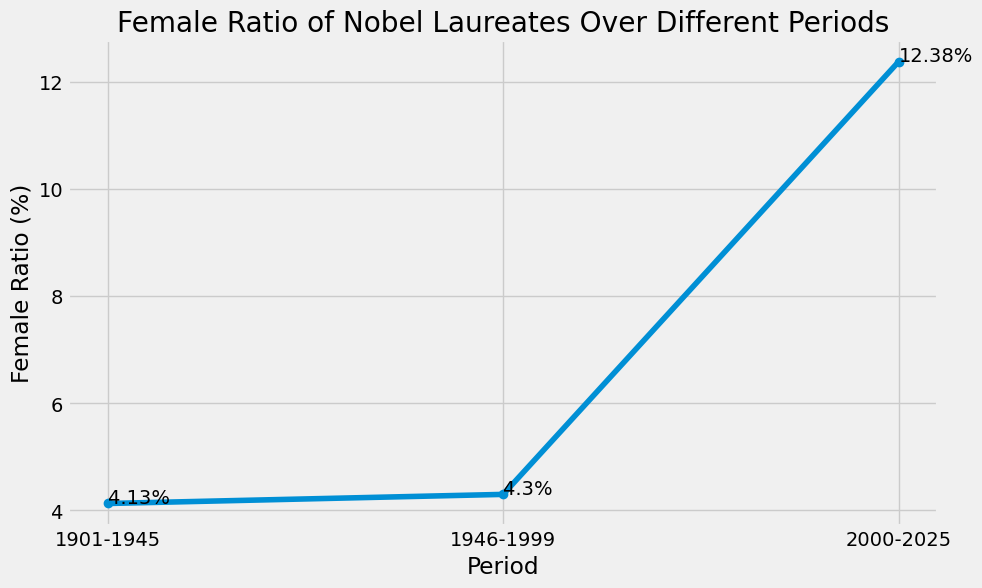

In [14]:
# Female Ratio Over Different Periods

df = final_df.copy()
df = df.drop_duplicates(subset=['Laureate ID'])

def year_range(year):
    if 1901 <= year <= 1945:
        return '1901-1945'
    elif 1946 <= year <= 1999:
        return '1946-1999'
    else:
        return '2000-2025'

counts_sex = df.copy()
counts_sex['Period'] = df['Year'].apply(year_range)
counts_period = counts_sex.groupby(['Period', 'Sex']).size().unstack(fill_value=0)
counts_period['Total'] = counts_period['Male'] + counts_period['Female']
counts_period['Female Ratio (%)'] = (counts_period['Female'] / counts_period['Total'] * 100).round(2)
print(counts_period)

plt.figure(figsize=(10, 6))
plt.plot(counts_period.index, counts_period['Female Ratio (%)'], marker='o')
plt.title('Female Ratio of Nobel Laureates Over Different Periods')
plt.xlabel('Period')
plt.ylabel('Female Ratio (%)')
for i, ratio in enumerate(counts_period['Female Ratio (%)']):
    plt.text(i, ratio, f'{ratio}%')
plt.grid(True)
plt.show()

### **Findings**
However, if we see the female ratio of nobel laureates over different periods, it dramatically increase after 21th century, where the female in the society facing less discrimination compared to centuries before.

Organization Name
University of California                        40
Harvard University                              27
Massachusetts Institute of Technology (MIT)     24
Stanford University                             20
University of Chicago                           20
Columbia University                             18
California Institute of Technology (Caltech)    18
University of Cambridge                         17
Princeton University                            17
Howard Hughes Medical Institute                 11
Name: count, dtype: int64


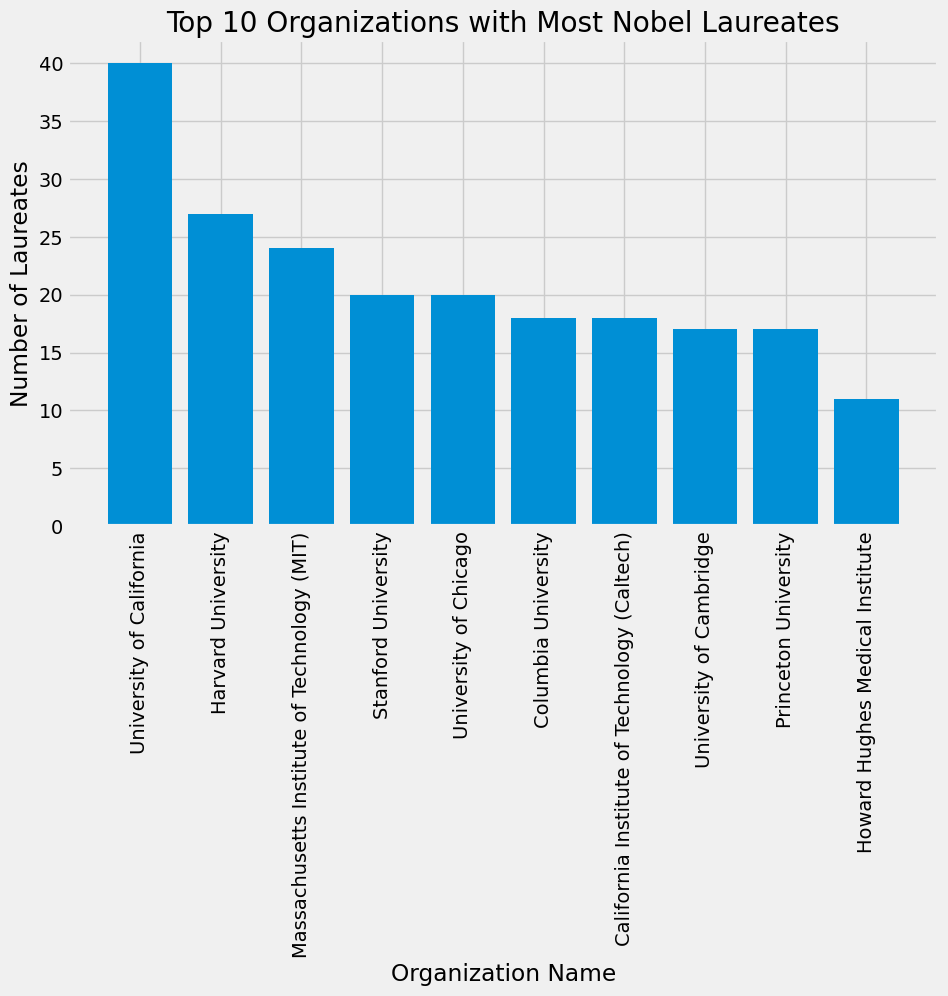

Organization City
Berkeley, CA         22
Santa Barbara, CA     7
Los Angeles, CA       6
San Francisco, CA     5
Irvine, CA            3
San Diego, CA         2
Name: count, dtype: int64


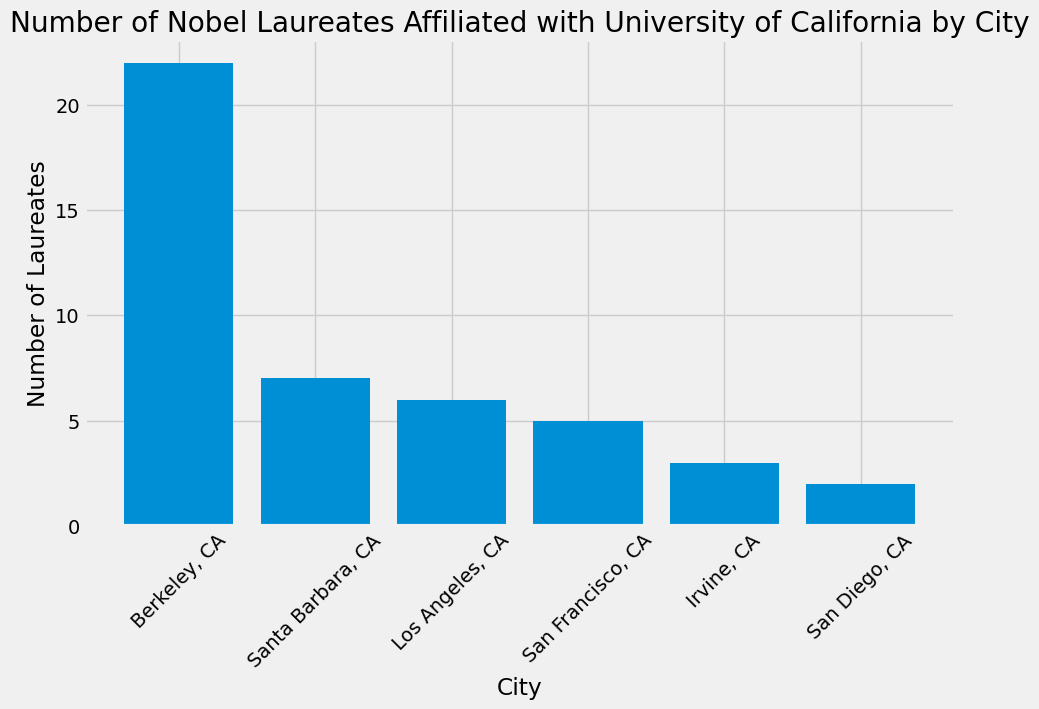

In [16]:
# Top 10 Organizations with Most Nobel Laureates

df = final_df.copy()
df = df.drop_duplicates(subset=['Laureate ID'])
counts_org = df.dropna(subset=['Organization Name'])
counts_org = counts_org['Organization Name'].value_counts()

top10 = counts_org.head(10)
print(top10)

plt.figure(figsize=(10,6))
plt.bar(top10.index, top10.values)
plt.title('Top 10 Organizations with Most Nobel Laureates')
plt.xlabel('Organization Name')
plt.ylabel('Number of Laureates')
plt.xticks(rotation=90)
plt.show()

# Cities with Most Nobel Laureates Affiliated with University of California
uc_df = df[df['Organization Name'].str.contains('University of California', na=False)]
uc_city = uc_df['Organization City'].value_counts()

print(uc_city)
plt.figure(figsize=(10, 6))
plt.bar(uc_city.index, uc_city.values)
plt.title('Number of Nobel Laureates Affiliated with University of California by City')
plt.xlabel('City')
plt.ylabel('Number of Laureates')
plt.xticks(rotation=45)
plt.show()


### **Findings**
I also want to see top 10 universities or organizations that have the most nobel prizes, and it shows that the University of California has significantly the most nobe laureates. This is becuase that under the organization of University of California, there are multiple universities. But still, if we break the UC in to different universities from different cities, UC Berkeley are compatitive and can be ranked top 10 universities around the world.